# 매장 프로모션 분석: 진열 × 전단

상품·매장·주차 단위로 진열(display)과 전단(mailer) 노출 조합에 따른 판매 및 장바구니 동시구매 차이를 분석합니다.

- 진열만: display≠0, mailer=0
- 전단만: display=0, mailer≠0
- 진열+전단: display≠0, mailer≠0

`causal_data.csv`에는 display=0, mailer=0인 행이 없어서 노출 없음 대조군을 직접 구성할 수 없습니다. 따라서 상품×매장×주차 분석은 세 가지 프로모션 조합끼리 비교하고, 진열만을 참고 기준으로 사용합니다. 코드별 정확한 위치·전단 유형 명칭은 별도 데이터 사전이 없으므로 임의로 해석하지 않습니다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "data" / "processed"
TRANSACTION_PATH = PROJECT_DIR / "transaction_data.csv"
CAUSAL_PATH = PROJECT_DIR / "causal_data.csv"
PRODUCT_PATH = PROJECT_DIR / "product.csv"
CHUNK_SIZE = 1_000_000

## 1. 거래를 상품×매장×주차 단위로 집계

In [2]:
tx = pd.read_csv(
    TRANSACTION_PATH,
    usecols=["household_key","BASKET_ID","PRODUCT_ID","STORE_ID","WEEK_NO","QUANTITY","SALES_VALUE"],
    dtype={"household_key":"int32","BASKET_ID":"int64","PRODUCT_ID":"int32",
           "STORE_ID":"int32","WEEK_NO":"int16","QUANTITY":"int32","SALES_VALUE":"float32"},
)
products = pd.read_csv(PRODUCT_PATH, usecols=["PRODUCT_ID","DEPARTMENT","COMMODITY_DESC"])
key_cols = ["PRODUCT_ID","STORE_ID","WEEK_NO"]
tx_week = tx.groupby(key_cols).agg(
    revenue=("SALES_VALUE","sum"), units=("QUANTITY","sum"),
    baskets=("BASKET_ID","nunique"), households=("household_key","nunique")
).reset_index()
tx_keys = tx_week[key_cols].drop_duplicates()
print(f"거래 행: {len(tx):,}")
print(f"판매가 발생한 상품×매장×주차: {len(tx_week):,}")

거래 행: 2,595,732
판매가 발생한 상품×매장×주차: 2,370,784


## 2. 3,678만 노출 행을 청크로 처리

판매가 없던 상품×매장×주차도 0으로 포함해야 판매 발생률을 비교할 수 있습니다. 전체 노출 테이블을 한 번에 메모리에 올리지 않고 청크별로 집계합니다.

In [3]:
overall_parts, category_parts, exposure_lookup_parts = [], [], []
causal_dtype = {"PRODUCT_ID":"int32","STORE_ID":"int32","WEEK_NO":"int16","display":"string","mailer":"string"}
for chunk_no, causal in enumerate(pd.read_csv(CAUSAL_PATH, chunksize=CHUNK_SIZE, dtype=causal_dtype), start=1):
    causal["display_flag"] = causal["display"].fillna("0").ne("0")
    causal["mailer_flag"] = causal["mailer"].fillna("0").ne("0")
    causal["promo_group"] = np.select(
        [causal["display_flag"] & causal["mailer_flag"], causal["display_flag"], causal["mailer_flag"]],
        ["진열+전단", "진열만", "전단만"], default="확인 필요"
    )
    joined = causal.merge(tx_week, on=key_cols, how="left", validate="many_to_one")
    for col in ["revenue","units","baskets","households"]: joined[col] = joined[col].fillna(0)
    joined["has_sale"] = joined["revenue"].gt(0).astype(int)
    overall_parts.append(joined.groupby(["WEEK_NO","promo_group"]).agg(
        observations=("PRODUCT_ID","size"), sales_observations=("has_sale","sum"),
        revenue=("revenue","sum"), units=("units","sum"), baskets=("baskets","sum")
    ).reset_index())
    by_category = joined.merge(products, on="PRODUCT_ID", how="left", validate="many_to_one")
    category_parts.append(by_category.groupby(["DEPARTMENT","COMMODITY_DESC","promo_group"], dropna=False).agg(
        observations=("PRODUCT_ID","size"), sales_observations=("has_sale","sum"),
        revenue=("revenue","sum"), units=("units","sum")
    ).reset_index())
    exposure_lookup_parts.append(causal.merge(tx_keys, on=key_cols, how="inner")
                                 [key_cols + ["display_flag","mailer_flag"]])
    if chunk_no % 10 == 0: print(f"{chunk_no:,}개 청크 처리 완료")
print("노출 데이터 청크 처리 완료")

10개 청크 처리 완료
20개 청크 처리 완료
30개 청크 처리 완료
노출 데이터 청크 처리 완료


## 3. 진열·전단 조합별 판매 차이

In [4]:
promotion_week = pd.concat(overall_parts).groupby(["WEEK_NO","promo_group"], as_index=False).sum(numeric_only=True)
promotion_week["sales_incidence"] = promotion_week["sales_observations"] / promotion_week["observations"]
promotion_week["revenue_per_observation"] = promotion_week["revenue"] / promotion_week["observations"]
promotion_week["units_per_observation"] = promotion_week["units"] / promotion_week["observations"]
store_promotion_summary = promotion_week.groupby("promo_group").agg(
    observations=("observations","sum"), sales_observations=("sales_observations","sum"),
    revenue=("revenue","sum"), units=("units","sum"), baskets=("baskets","sum")
).reset_index()
store_promotion_summary["sales_incidence"] = store_promotion_summary["sales_observations"] / store_promotion_summary["observations"]
store_promotion_summary["revenue_per_observation"] = store_promotion_summary["revenue"] / store_promotion_summary["observations"]
store_promotion_summary["units_per_observation"] = store_promotion_summary["units"] / store_promotion_summary["observations"]
baseline = store_promotion_summary.set_index("promo_group").loc["진열만"]
store_promotion_summary["sales_incidence_lift_vs_display_only"] = store_promotion_summary["sales_incidence"] / baseline["sales_incidence"]
store_promotion_summary["revenue_lift_vs_display_only"] = store_promotion_summary["revenue_per_observation"] / baseline["revenue_per_observation"]
display(store_promotion_summary.sort_values("revenue_lift_vs_display_only", ascending=False))

,promo_group,observations,sales_observations,revenue,units,baskets,sales_incidence,revenue_per_observation,units_per_observation,sales_incidence_lift_vs_display_only,revenue_lift_vs_display_only
1,진열+전단,4213596,103205,319381.65625,182136.0,124026.0,0.024493,0.075798,0.043226,2.129343,2.158294
0,전단만,21038745,245342,834774.37500,413684.0,290981.0,0.011661,0.039678,0.019663,1.013794,1.129803
2,진열만,11534183,132675,405072.93750,200309.0,149625.0,0.011503,0.035119,0.017367,1.000000,1.000000


/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_35163/4011543163.py:5: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_35163/4011543163.py:5: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_35163/4011543163.py:5: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_35163/4011543163.py:5: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_35163/4011543163.py:5: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x6

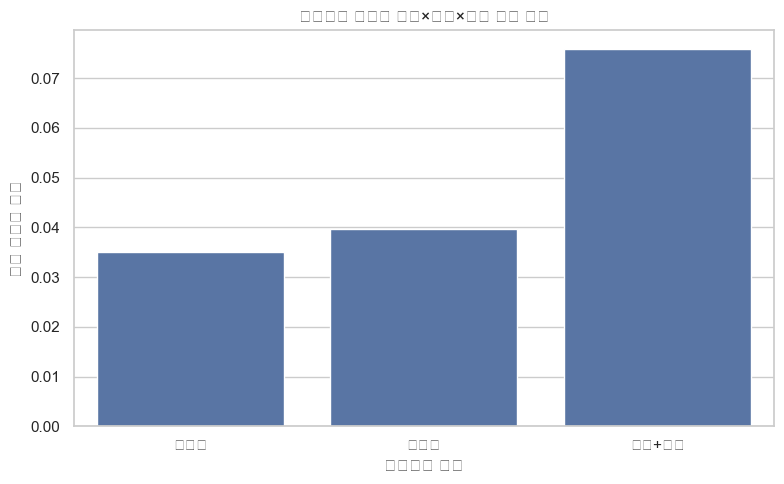

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(data=store_promotion_summary, x="promo_group", y="revenue_per_observation", order=["진열만","전단만","진열+전단"])
plt.title("프로모션 조합별 상품×매장×주차 평균 매출")
plt.xlabel("프로모션 조합"); plt.ylabel("관측 단위당 매출")
plt.tight_layout(); plt.show()

## 4. 카테고리별 프로모션 반응

전체 평균은 프로모션 대상 상품 선택의 영향을 받을 수 있으므로 같은 카테고리 안에서 진열만 대비 매출 비율을 비교합니다. 관측치가 너무 작은 조합은 제외합니다.

In [6]:
category_summary = pd.concat(category_parts).groupby(["DEPARTMENT","COMMODITY_DESC","promo_group"], dropna=False, as_index=False).sum(numeric_only=True)
category_summary["sales_incidence"] = category_summary["sales_observations"] / category_summary["observations"]
category_summary["revenue_per_observation"] = category_summary["revenue"] / category_summary["observations"]
category_baseline = category_summary.loc[category_summary["promo_group"] == "진열만", ["DEPARTMENT","COMMODITY_DESC","revenue_per_observation"]]
category_baseline = category_baseline.rename(columns={"revenue_per_observation":"baseline_revenue_per_observation"})
store_promotion_category_summary = category_summary.merge(category_baseline, on=["DEPARTMENT","COMMODITY_DESC"], how="left")
store_promotion_category_summary["revenue_lift_vs_display_only"] = store_promotion_category_summary["revenue_per_observation"] / store_promotion_category_summary["baseline_revenue_per_observation"].replace(0,np.nan)
reliable_categories = store_promotion_category_summary.query("promo_group != '진열만' and observations >= 1000 and sales_observations >= 30")
display(reliable_categories.sort_values("revenue_lift_vs_display_only", ascending=False).head(20))

,DEPARTMENT,COMMODITY_DESC,promo_group,observations,sales_observations,revenue,units,sales_incidence,revenue_per_observation,baseline_revenue_per_observation,revenue_lift_vs_display_only
819,SEAFOOD,SEAFOOD-FRESH,전단만,15514,480,3473.479980,582.0,0.030940,0.223893,0.010144,22.071615
799,PRODUCE,VALUE ADDED FRUIT,전단만,5725,132,531.059998,149.0,0.023057,0.092762,0.006358,14.588865
598,MEAT,SMOKED MEATS,전단만,20203,528,7159.700684,608.0,0.026135,0.354388,0.025895,13.685671
17,COUP/STR & MFG,COUPONS/STORE & MFG,전단만,2673,36,93.110001,38.0,0.013468,0.034834,0.004524,7.700346
788,PRODUCE,SEASONAL,전단만,1374,41,286.179993,76.0,0.029840,0.208282,0.029556,7.047148
607,MEAT-PCKGD,BACON,진열+전단,52082,2777,11989.270508,4916.0,0.053320,0.230200,0.032888,6.999532
32,DELI,PARTY TRAYS,전단만,14322,92,1316.040039,97.0,0.006424,0.091889,0.015247,6.026575
584,MEAT,BEEF,전단만,364620,13239,106252.578125,23528.0,0.036309,0.291406,0.050556,5.764060
585,MEAT,BEEF,진열+전단,1176,37,309.049988,76.0,0.031463,0.262798,0.050556,5.198175
21,DELI,CHEESES,전단만,86443,1158,3971.010010,1308.0,0.013396,0.045938,0.009267,4.957099


## 5. 프로모션 상품이 포함된 장바구니의 동시구매

거래가 발생한 상품의 노출 상태를 장바구니에 연결합니다. 장바구니에 진열·전단 상품이 하나라도 있으면 해당 플래그를 부여하고, 장바구니 매출·상품 수·카테고리 수를 비교합니다. 큰 장바구니일수록 프로모션 상품을 하나라도 포함할 확률 자체가 높으므로, 이 결과는 탐색적 연관성으로만 해석합니다.

In [7]:
exposure_lookup = pd.concat(exposure_lookup_parts).groupby(key_cols, as_index=False).agg(
    display_flag=("display_flag","max"), mailer_flag=("mailer_flag","max")
)
tx_exposed = tx.merge(exposure_lookup, on=key_cols, how="left")
tx_exposed[["display_flag","mailer_flag"]] = tx_exposed[["display_flag","mailer_flag"]].fillna(False)
tx_exposed = tx_exposed.merge(products, on="PRODUCT_ID", how="left", validate="many_to_one")
basket = tx_exposed.groupby("BASKET_ID").agg(
    basket_revenue=("SALES_VALUE","sum"), basket_units=("QUANTITY","sum"),
    unique_products=("PRODUCT_ID","nunique"), unique_categories=("COMMODITY_DESC","nunique"),
    has_display=("display_flag","max"), has_mailer=("mailer_flag","max")
).reset_index()
basket["promo_group"] = np.select(
    [basket["has_display"] & basket["has_mailer"], basket["has_display"], basket["has_mailer"]],
    ["진열+전단","진열만","전단만"], default="노출 없음"
)
store_promotion_basket_summary = basket.groupby("promo_group").agg(
    baskets=("BASKET_ID","size"), avg_basket_revenue=("basket_revenue","mean"),
    median_basket_revenue=("basket_revenue","median"), median_basket_units=("basket_units","median"),
    avg_unique_products=("unique_products","mean"),
    avg_unique_categories=("unique_categories","mean")
).reset_index()
display(store_promotion_basket_summary)

,promo_group,baskets,avg_basket_revenue,median_basket_revenue,median_basket_units,avg_unique_products,avg_unique_categories
0,노출 없음,126168,15.571728,10.000000,4.0,3.436371,2.776251
1,전단만,42365,25.274229,16.630001,8.0,8.671403,6.736811
2,진열+전단,86739,52.918156,38.619999,19.0,19.059639,13.492593
3,진열만,21212,20.365778,13.800000,6.0,6.675184,5.189798


## 6. 해석 원칙

- `sales_incidence_lift_vs_display_only > 1`: 판매 발생률이 진열만보다 높음
- `revenue_lift_vs_display_only > 1`: 관측 단위당 매출이 진열만보다 높음
- `avg_unique_categories` 증가: 프로모션 상품이 포함된 장바구니에서 카테고리 동시구매 폭이 더 큼. 단, 큰 장바구니가 프로모션 상품을 포함할 확률이 높은 기계적 편향이 있음
- 수량에는 극단값이 있어 평균 대신 `median_basket_units`를 우선 해석
- causal_data에 완전한 무노출 행이 없으므로 프로모션 대 무프로모션 효과로 해석하면 안 됨
- 전체 평균이 높아도 원래 잘 팔리는 상품을 특정 조합에 선정했기 때문일 수 있으므로 카테고리별 결과와 함께 확인
- 실제 실행 전략에서는 규제 상품, 마진, 프로모션 비용, 재고를 추가로 고려해야 함

In [8]:
store_promotion_summary.to_csv(OUTPUT_DIR / "store_promotion_summary.csv", index=False, encoding="utf-8-sig")
store_promotion_category_summary.to_csv(OUTPUT_DIR / "store_promotion_category_summary.csv", index=False, encoding="utf-8-sig")
store_promotion_basket_summary.to_csv(OUTPUT_DIR / "store_promotion_basket_summary.csv", index=False, encoding="utf-8-sig")
print("결과 3개 저장 완료")

결과 3개 저장 완료
